# Predictive Maintenance for Industrial Equipment Using NASA C-MAPSS Multi-Dataset Time-Series Data

## Project Overview

Predictive maintenance is an advanced maintenance strategy that uses machine learning techniques to predict equipment failures before they occur.

This project aims to develop a Machine Learning based Remaining Useful Life (RUL) prediction system for aircraft turbofan engines using the NASA C-MAPSS (Commercial Modular Aero-Propulsion System Simulation) dataset.

The model analyzes historical time-series sensor measurements collected from turbofan engines and predicts the remaining operational cycles before failure.

By accurately estimating RUL, maintenance teams can schedule preventive maintenance, reduce unexpected failures, minimize downtime, and improve equipment reliability.


## Objective

The main objectives of this project are:

- Analyze turbofan engine degradation patterns using sensor data.
- Calculate Remaining Useful Life (RUL) from historical engine cycles.
- Develop and compare multiple machine learning regression models.
- Evaluate models using appropriate regression metrics.
- Apply time-series cross-validation for robust evaluation.
- Optimize model performance using hyperparameter tuning.
- Generate maintenance recommendations based on predicted RUL values.


## Dataset

The project uses the NASA C-MAPSS Turbofan Engine Dataset.

The following four subsets are used:

- FD001
- FD002
- FD003
- FD004


Each dataset contains:

- Engine identification number
- Operating cycles
- Operational settings
- Sensor measurements collected during engine operation


## Machine Learning Approach

The complete workflow includes:

Data Loading  
↓  
Data Understanding  
↓  
Data Preprocessing  
↓  
RUL Calculation  
↓  
Exploratory Data Analysis  
↓  
Feature Engineering  
↓  
Feature Scaling  
↓  
Model Training  
↓  
Model Comparison  
↓  
Time-Series Cross Validation  
↓  
Hyperparameter Optimization  
↓  
Final RUL Prediction  
↓  
Maintenance Recommendation


## Technologies Used

Programming Language:

- Python


Libraries:

- Pandas
- NumPy
- Scikit-learn
- XGBoost
- Matplotlib
- Seaborn
- Joblib


## Expected Outcome

A complete predictive maintenance pipeline capable of:

- Predicting Remaining Useful Life of turbofan engines.
- Comparing multiple machine learning models.
- Handling multiple operating conditions.
- Supporting proactive maintenance scheduling.

In [ ]:
# Import required libraries

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning preprocessing
from sklearn.preprocessing import StandardScaler

# Model training
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor

# Model evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Cross validation and optimization
from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV
)

# Model saving
import joblib

# File handling
import os
import warnings

# Ignore warnings
warnings.filterwarnings("ignore")


print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_PATH = "/content/drive/MyDrive/CMaps"

print(DATA_PATH)


/content/drive/MyDrive/CMaps


In [ ]:
import os

files = os.listdir(DATA_PATH)

for file in files:
    print(file)

RUL_FD004.txt
train_FD001.txt
train_FD003.txt
RUL_FD002.txt
RUL_FD003.txt
RUL_FD001.txt
test_FD002.txt
test_FD004.txt
train_FD002.txt
test_FD001.txt
train_FD004.txt
test_FD003.txt


Define NASA C-MAPSS Column Names

In [ ]:
# Define column names for NASA C-MAPSS dataset

columns = [
    "engine_id",
    "cycle",
    "setting_1",
    "setting_2",
    "setting_3"
]

# Add 21 sensor columns

for i in range(1, 22):
    columns.append(f"sensor_{i}")

print("Total columns:", len(columns))

columns

Total columns: 26


['engine_id',
 'cycle',
 'setting_1',
 'setting_2',
 'setting_3',
 'sensor_1',
 'sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_5',
 'sensor_6',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_10',
 'sensor_11',
 'sensor_12',
 'sensor_13',
 'sensor_14',
 'sensor_15',
 'sensor_16',
 'sensor_17',
 'sensor_18',
 'sensor_19',
 'sensor_20',
 'sensor_21']

Create Function to Load NASA C-MAPSS Dataset

In [ ]:
# Function to load NASA C-MAPSS data

def load_cmapss_data(dataset_name):

    train_file = f"{DATA_PATH}/train_{dataset_name}.txt"
    test_file = f"{DATA_PATH}/test_{dataset_name}.txt"
    rul_file = f"{DATA_PATH}/RUL_{dataset_name}.txt"


    # Load training data
    train_data = pd.read_csv(
        train_file,
        sep=r"\s+",
        header=None
    )

    # Load testing data
    test_data = pd.read_csv(
        test_file,
        sep=r"\s+",
        header=None
    )

    # Load RUL values
    rul_data = pd.read_csv(
        rul_file,
        sep=r"\s+",
        header=None
    )


    # Assign column names
    train_data.columns = columns
    test_data.columns = columns


    return train_data, test_data, rul_data


print("Dataset loading function created successfully!")

Dataset loading function created successfully!


Load All Four NASA C-MAPSS Datasets and Check Shapes

In [ ]:
# Load all NASA C-MAPSS datasets

dataset_names = [
    "FD001",
    "FD002",
    "FD003",
    "FD004"
]


data = {}


for dataset in dataset_names:

    train, test, rul = load_cmapss_data(dataset)

    data[dataset] = {
        "train": train,
        "test": test,
        "rul": rul
    }

    print(dataset)
    print("----------------")
    print("Training shape:", train.shape)
    print("Testing shape :", test.shape)
    print("RUL shape     :", rul.shape)
    print()

FD001
----------------
Training shape: (20631, 26)
Testing shape : (13096, 26)
RUL shape     : (100, 1)

FD002
----------------
Training shape: (53759, 26)
Testing shape : (33991, 26)
RUL shape     : (259, 1)

FD003
----------------
Training shape: (24720, 26)
Testing shape : (16596, 26)
RUL shape     : (100, 1)

FD004
----------------
Training shape: (61249, 26)
Testing shape : (41214, 26)
RUL shape     : (248, 1)



 Display First Rows and Understand Dataset Structure

In [ ]:
# Display first 5 rows of each dataset

for dataset in dataset_names:

    print("\nDataset:", dataset)
    print("----------------------------")

    display(data[dataset]["train"].head())


Dataset: FD001
----------------------------


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044



Dataset: FD002
----------------------------


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,183.06,2387.72,8048.56,9.3461,0.02,334,2223,100.00,14.73,8.8071
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,130.42,2387.66,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,164.22,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,130.72,2387.61,8068.66,9.3528,0.02,329,2212,100.00,10.59,6.4701
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,164.31,2028.00,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286



Dataset: FD003
----------------------------


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0005,0.0004,100.0,518.67,642.36,1583.23,1396.84,14.62,...,522.31,2388.01,8145.32,8.4246,0.03,391,2388,100.0,39.11,23.3537
1,1,2,0.0008,-0.0003,100.0,518.67,642.50,1584.69,1396.89,14.62,...,522.42,2388.03,8152.85,8.4403,0.03,392,2388,100.0,38.99,23.4491
2,1,3,-0.0014,-0.0002,100.0,518.67,642.18,1582.35,1405.61,14.62,...,522.03,2388.00,8150.17,8.3901,0.03,391,2388,100.0,38.85,23.3669
3,1,4,-0.0020,0.0001,100.0,518.67,642.92,1585.61,1392.27,14.62,...,522.49,2388.08,8146.56,8.3878,0.03,392,2388,100.0,38.96,23.2951
4,1,5,0.0016,0.0000,100.0,518.67,641.68,1588.63,1397.65,14.62,...,522.58,2388.03,8147.80,8.3869,0.03,392,2388,100.0,39.14,23.4583



Dataset: FD004
----------------------------


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754


 Dataset Information and Missing Value Check

In [ ]:
# Dataset information and missing value check

for dataset in dataset_names:

    print("\nDataset:", dataset)
    print("----------------------------")

    train_data = data[dataset]["train"]

    print("Shape:", train_data.shape)

    print("\nMissing Values:")
    print(train_data.isnull().sum().sum())


Dataset: FD001
----------------------------
Shape: (20631, 26)

Missing Values:
0

Dataset: FD002
----------------------------
Shape: (53759, 26)

Missing Values:
0

Dataset: FD003
----------------------------
Shape: (24720, 26)

Missing Values:
0

Dataset: FD004
----------------------------
Shape: (61249, 26)

Missing Values:
0


Calculate Remaining Useful Life (RUL) for All Datasets (Code Cell)

Now we create the target variable (RUL) for training data.

RUL formula:

RUL=Maximum Cycle of Engine−Current Cycle

In [ ]:
# Calculate RUL for training datasets

for dataset in dataset_names:

    train_data = data[dataset]["train"]

    # Find maximum cycle for each engine
    max_cycle = train_data.groupby("engine_id")["cycle"].max()

    # Create RUL column
    train_data["RUL"] = train_data.apply(
        lambda row: max_cycle[row["engine_id"]] - row["cycle"],
        axis=1
    )

    # Update dataset
    data[dataset]["train"] = train_data


    print(dataset, "RUL calculation completed")

FD001 RUL calculation completed
FD002 RUL calculation completed
FD003 RUL calculation completed
FD004 RUL calculation completed


In [ ]:
# Display FD001 with RUL column

data["FD001"]["train"].head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191.0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190.0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189.0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188.0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187.0


Analyze Engine Life Cycle Distribution (EDA)

In [ ]:
# Analyze engine life cycle distribution

for dataset in dataset_names:

    train_data = data[dataset]["train"]

    engine_cycles = train_data.groupby("engine_id")["cycle"].max()

    print("\nDataset:", dataset)
    print("----------------------------")
    print(engine_cycles.describe())


Dataset: FD001
----------------------------
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64

Dataset: FD002
----------------------------
count    260.000000
mean     206.765385
std       46.782198
min      128.000000
25%      174.000000
50%      199.000000
75%      230.250000
max      378.000000
Name: cycle, dtype: float64

Dataset: FD003
----------------------------
count    100.00000
mean     247.20000
std       86.48384
min      145.00000
25%      189.75000
50%      220.50000
75%      279.75000
max      525.00000
Name: cycle, dtype: float64

Dataset: FD004
----------------------------
count    249.00000
mean     245.97992
std       73.11080
min      128.00000
25%      190.00000
50%      234.00000
75%      290.00000
max      543.00000
Name: cycle, dtype: float64


RUL Distribution Visualization (EDA)

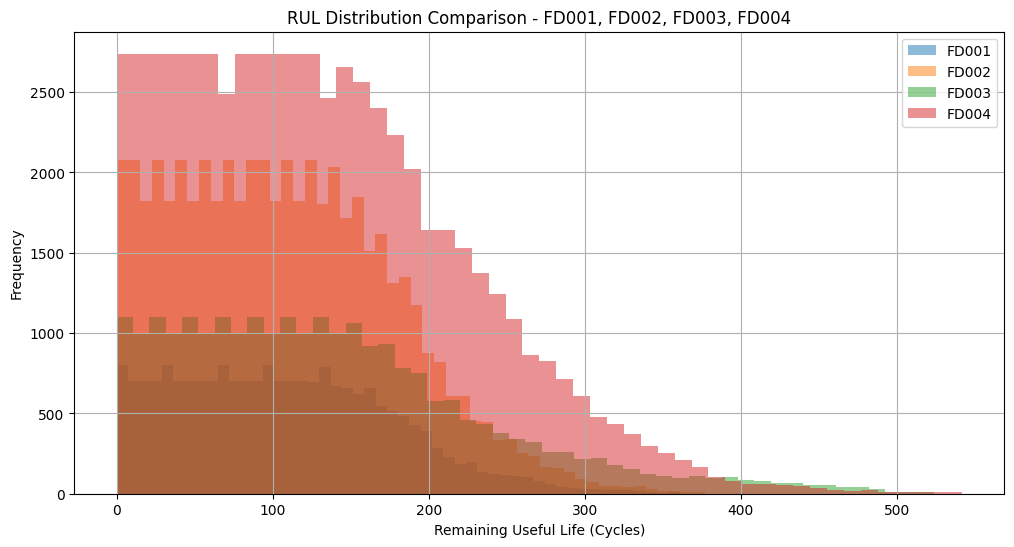

In [ ]:
import matplotlib.pyplot as plt

# Combined RUL distribution for all datasets

plt.figure(figsize=(12,6))

for dataset in dataset_names:

    rul_values = data[dataset]["train"]["RUL"]

    plt.hist(
        rul_values,
        bins=50,
        alpha=0.5,
        label=dataset
    )

plt.xlabel("Remaining Useful Life (Cycles)")
plt.ylabel("Frequency")
plt.title("RUL Distribution Comparison - FD001, FD002, FD003, FD004")

plt.legend()
plt.grid(True)
plt.savefig("rul_distribution.png", dpi=150, bbox_inches="tight")

plt.show()

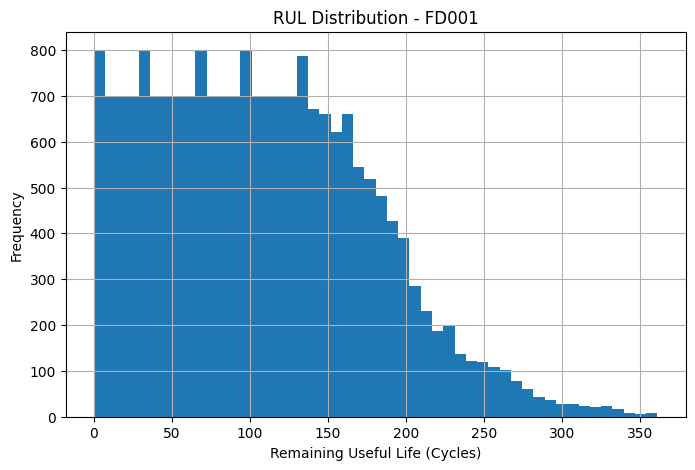

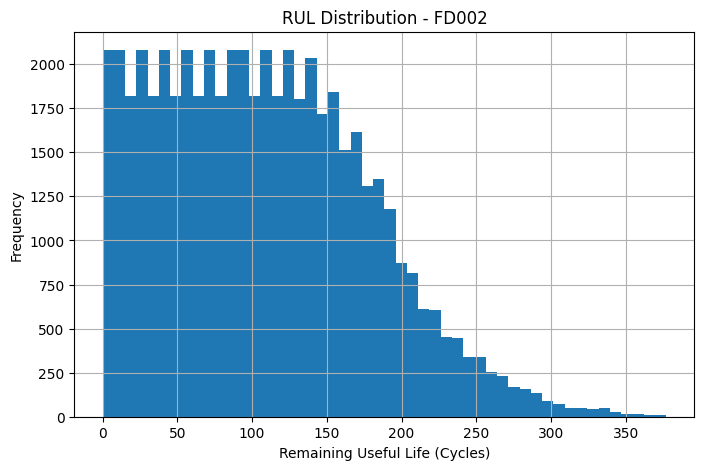

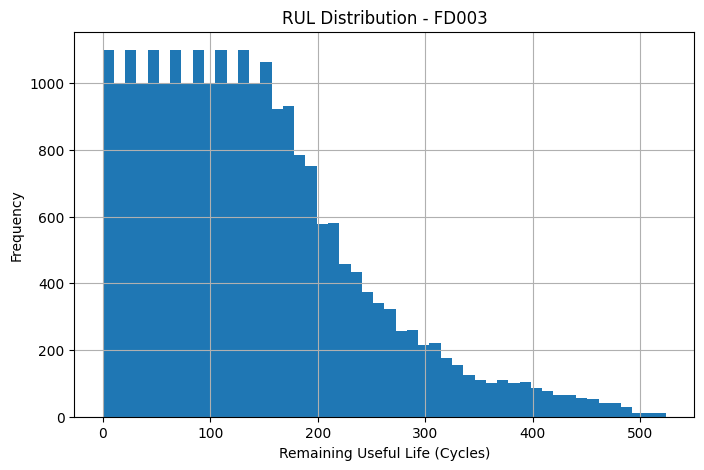

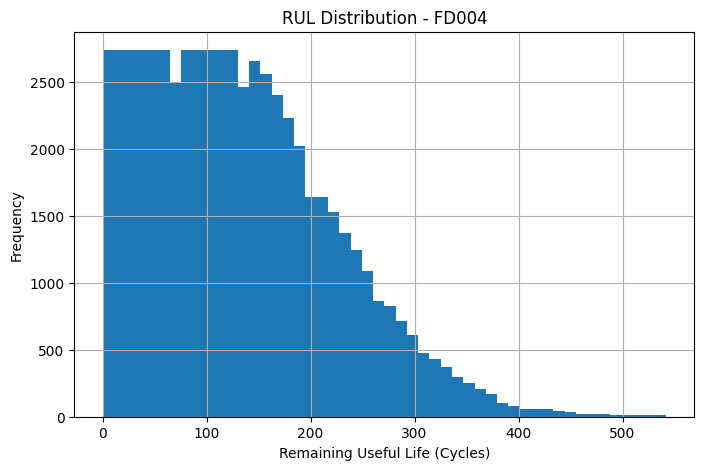

In [ ]:
# Individual RUL distribution plots

for dataset in dataset_names:

    plt.figure(figsize=(8,5))

    plt.hist(
        data[dataset]["train"]["RUL"],
        bins=50
    )

    plt.xlabel("Remaining Useful Life (Cycles)")
    plt.ylabel("Frequency")
    plt.title(f"RUL Distribution - {dataset}")

    plt.grid(True)
    plt.show()

Sensor Analysis (Find Constant Sensors)

In [ ]:
# Check constant sensors in all datasets

for dataset in dataset_names:

    train_data = data[dataset]["train"]

    sensor_columns = [
        col for col in train_data.columns
        if "sensor" in col
    ]

    constant_sensors = []

    for sensor in sensor_columns:

        if train_data[sensor].nunique() == 1:
            constant_sensors.append(sensor)

    print("\nDataset:", dataset)
    print("----------------------------")

    if len(constant_sensors) > 0:
        print("Constant Sensors:")
        print(constant_sensors)
    else:
        print("No constant sensors found")


Dataset: FD001
----------------------------
Constant Sensors:
['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

Dataset: FD002
----------------------------
No constant sensors found

Dataset: FD003
----------------------------
Constant Sensors:
['sensor_1', 'sensor_5', 'sensor_16', 'sensor_18', 'sensor_19']

Dataset: FD004
----------------------------
No constant sensors found


Remove Constant Sensors and Create Clean Dataset

In [ ]:
# Remove constant sensors from all datasets

clean_data = {}

for dataset in dataset_names:

    train_data = data[dataset]["train"].copy()
    test_data = data[dataset]["test"].copy()

    sensor_columns = [
        col for col in train_data.columns
        if "sensor" in col
    ]

    constant_sensors = [
        sensor for sensor in sensor_columns
        if train_data[sensor].nunique() == 1
    ]

    # Drop constant sensors
    train_data = train_data.drop(columns=constant_sensors)
    test_data = test_data.drop(columns=constant_sensors)

    clean_data[dataset] = {
        "train": train_data,
        "test": test_data
    }

    print(dataset)
    print("Removed sensors:", constant_sensors)
    print("New shape:", train_data.shape)
    print("----------------------------")

FD001
Removed sensors: ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
New shape: (20631, 21)
----------------------------
FD002
Removed sensors: []
New shape: (53759, 27)
----------------------------
FD003
Removed sensors: ['sensor_1', 'sensor_5', 'sensor_16', 'sensor_18', 'sensor_19']
New shape: (24720, 22)
----------------------------
FD004
Removed sensors: []
New shape: (61249, 27)
----------------------------


 Sensor Correlation Analysis with RUL

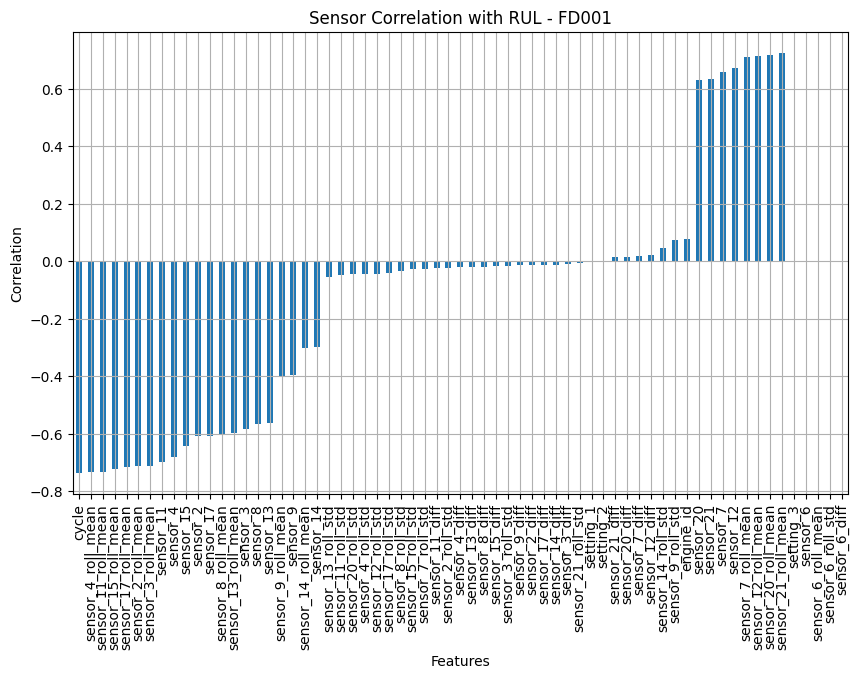

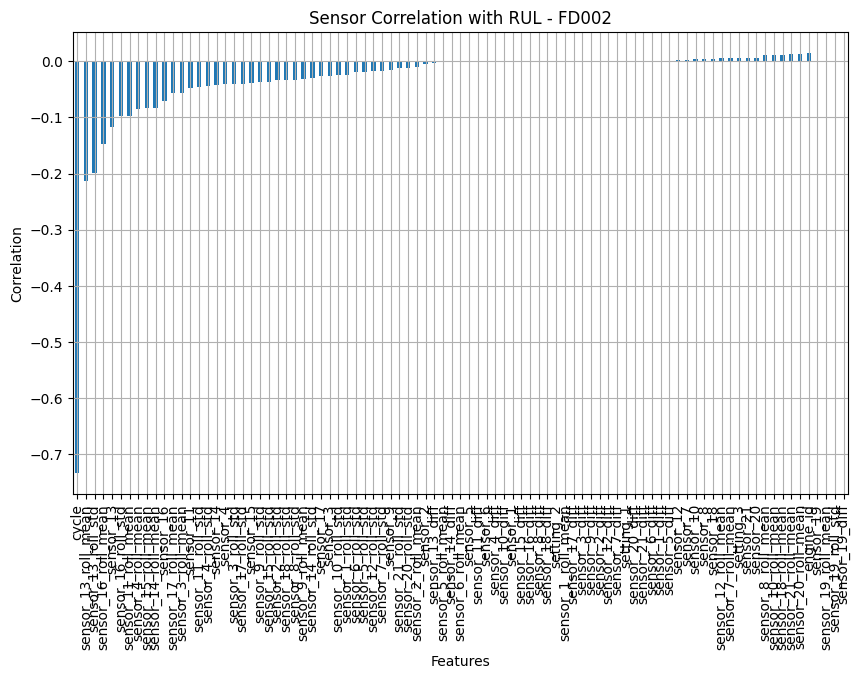

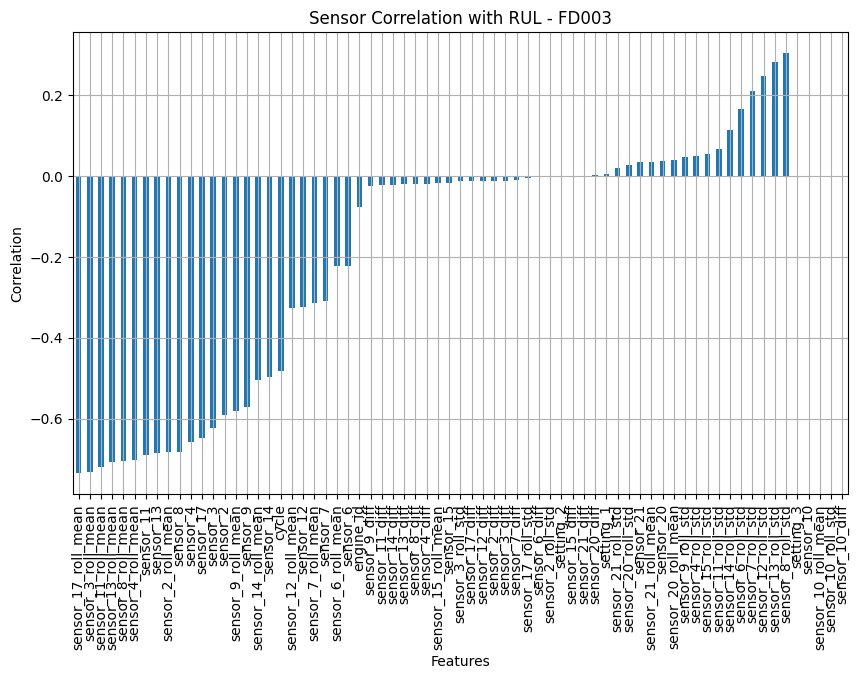

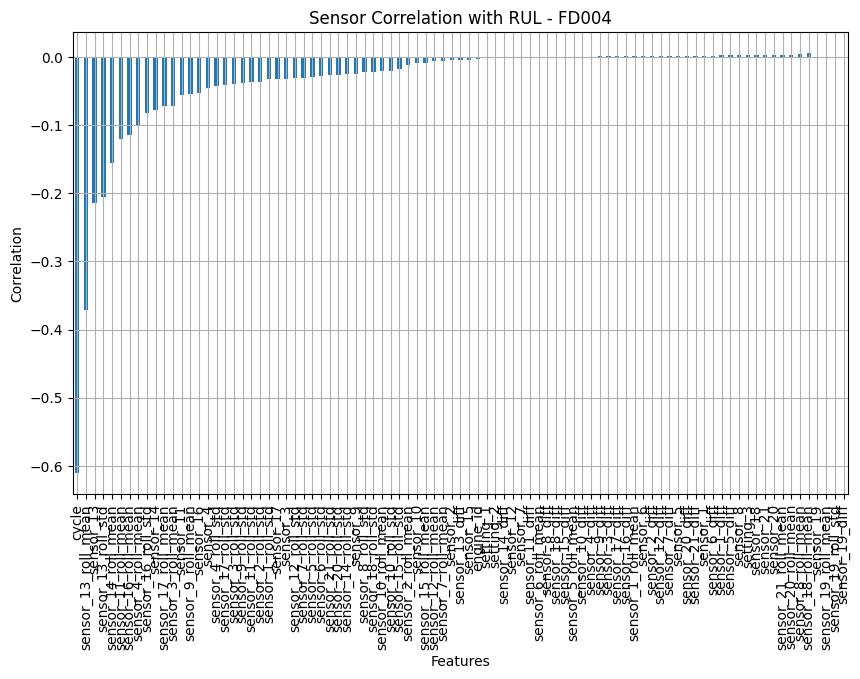

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation analysis for all datasets

for dataset in dataset_names:

    train_data = clean_data[dataset]["train"]

    correlation = train_data.corr()["RUL"].sort_values()

    plt.figure(figsize=(10,6))

    correlation.drop(["RUL"]).plot(kind="bar")

    plt.title(f"Sensor Correlation with RUL - {dataset}")
    plt.xlabel("Features")
    plt.ylabel("Correlation")
    plt.xticks(rotation=90)
    plt.grid(True)
    plt.savefig("sensor_correlation_heatmap.png")

    plt.show()

 Handle Missing/Corrupted Sensor Data

In [ ]:
# Handle missing and corrupted (outlier) sensor values
# C-MAPSS is clean, but this makes the pipeline robust for real-world noisy data

def handle_missing_and_outliers(df, sensor_cols):
    df = df.copy()

    # Fill missing values within each engine (sensors change gradually cycle to cycle)
    df[sensor_cols] = df.groupby("engine_id")[sensor_cols].transform(
        lambda x: x.ffill().bfill()
    )

    # Cap extreme outliers (simulated corrupted spikes) using IQR per sensor
    for col in sensor_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 3 * IQR
        upper = Q3 + 3 * IQR
        df[col] = df[col].clip(lower, upper)

    return df


for dataset in dataset_names:

    train_data = clean_data[dataset]["train"]
    test_data = clean_data[dataset]["test"]

    sensor_cols = [col for col in train_data.columns if "sensor" in col]

    clean_data[dataset]["train"] = handle_missing_and_outliers(train_data, sensor_cols)
    clean_data[dataset]["test"] = handle_missing_and_outliers(test_data, sensor_cols)

    print(dataset, "- missing/outlier handling applied")

FD001 - missing/outlier handling applied
FD002 - missing/outlier handling applied
FD003 - missing/outlier handling applied
FD004 - missing/outlier handling applied


In [ ]:
# Feature engineering: rolling stats + rate-of-change to capture degradation trends

window_size = 5

for dataset in dataset_names:

    train_data = clean_data[dataset]["train"].copy()
    test_data = clean_data[dataset]["test"].copy()

    sensor_cols = [col for col in train_data.columns if "sensor" in col]

    for df in [train_data, test_data]:
        df.sort_values(["engine_id", "cycle"], inplace=True)

        for sensor in sensor_cols:
            df[f"{sensor}_roll_mean"] = (
                df.groupby("engine_id")[sensor]
                .transform(lambda x: x.rolling(window_size, min_periods=1).mean())
            )
            df[f"{sensor}_roll_std"] = (
                df.groupby("engine_id")[sensor]
                .transform(lambda x: x.rolling(window_size, min_periods=1).std().fillna(0))
            )
            df[f"{sensor}_diff"] = (
                df.groupby("engine_id")[sensor].diff().fillna(0)
            )

    clean_data[dataset]["train"] = train_data
    clean_data[dataset]["test"] = test_data

    print(dataset, "- new shape after feature engineering:", train_data.shape)

FD001 - new shape after feature engineering: (20631, 66)
FD002 - new shape after feature engineering: (53759, 90)
FD003 - new shape after feature engineering: (24720, 70)
FD004 - new shape after feature engineering: (61249, 90)


 —repare Features (X) and Target (y)

In [ ]:
# Prepare X and y for all datasets

prepared_data = {}

for dataset in dataset_names:

    train_data = clean_data[dataset]["train"].copy()

    # Separate target
    X = train_data.drop(columns=["RUL"])
    y = train_data["RUL"]

    prepared_data[dataset] = {
        "X": X,
        "y": y
    }

    print("Dataset:", dataset)
    print("----------------------------")
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print()

Dataset: FD001
----------------------------
X shape: (20631, 65)
y shape: (20631,)

Dataset: FD002
----------------------------
X shape: (53759, 89)
y shape: (53759,)

Dataset: FD003
----------------------------
X shape: (24720, 69)
y shape: (24720,)

Dataset: FD004
----------------------------
X shape: (61249, 89)
y shape: (61249,)



Train/Test Split Using Time-Series Approach

(Important because this is predictive maintenance time-series data and we must avoid data leakage.)

In [ ]:
from sklearn.model_selection import train_test_split

split_data = {}

for dataset in dataset_names:

    X = prepared_data[dataset]["X"]
    y = prepared_data[dataset]["y"]

    # Sort by engine and cycle to maintain time order
    sorted_indices = X.sort_values(
        ["engine_id", "cycle"]
    ).index

    X = X.loc[sorted_indices]
    y = y.loc[sorted_indices]

    # 80-20 time based split
    split_index = int(len(X) * 0.8)

    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]

    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    split_data[dataset] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

    print("Dataset:", dataset)
    print("----------------------------")
    print("X_train:", X_train.shape)
    print("X_test :", X_test.shape)
    print("y_train:", y_train.shape)
    print("y_test :", y_test.shape)
    print()

Dataset: FD001
----------------------------
X_train: (16504, 65)
X_test : (4127, 65)
y_train: (16504,)
y_test : (4127,)

Dataset: FD002
----------------------------
X_train: (43007, 89)
X_test : (10752, 89)
y_train: (43007,)
y_test : (10752,)

Dataset: FD003
----------------------------
X_train: (19776, 69)
X_test : (4944, 69)
y_train: (19776,)
y_test : (4944,)

Dataset: FD004
----------------------------
X_train: (48999, 89)
X_test : (12250, 89)
y_train: (48999,)
y_test : (12250,)



Feature Scaling Using StandardScaler

We will normalize sensor values before training:

Random Forest
Gradient Boosting
XGBoost

In [ ]:
from sklearn.preprocessing import StandardScaler

scaled_data = {}

for dataset in dataset_names:

    X_train = split_data[dataset]["X_train"]
    X_test = split_data[dataset]["X_test"]

    scaler = StandardScaler()

    # Fit only on training data
    X_train_scaled = scaler.fit_transform(X_train)

    # Transform test data
    X_test_scaled = scaler.transform(X_test)

    scaled_data[dataset] = {
        "X_train": X_train_scaled,
        "X_test": X_test_scaled,
        "y_train": split_data[dataset]["y_train"],
        "y_test": split_data[dataset]["y_test"],
        "scaler": scaler
    }

    print("Dataset:", dataset)
    print("----------------------------")
    print("Scaled X_train shape:", X_train_scaled.shape)
    print("Scaled X_test shape :", X_test_scaled.shape)
    print()

Dataset: FD001
----------------------------
Scaled X_train shape: (16504, 65)
Scaled X_test shape : (4127, 65)

Dataset: FD002
----------------------------
Scaled X_train shape: (43007, 89)
Scaled X_test shape : (10752, 89)

Dataset: FD003
----------------------------
Scaled X_train shape: (19776, 69)
Scaled X_test shape : (4944, 69)

Dataset: FD004
----------------------------
Scaled X_train shape: (48999, 89)
Scaled X_test shape : (12250, 89)



Train and Compare ML Models
Train three regression models on all four datasets:

Random Forest Regressor
Gradient Boosting Regressor
XGBoost Regressor

We will store:

Trained models
Predictions
Performance metrics

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


model_results = {}
trained_models = {}


for dataset in dataset_names:

    print("\nDataset:", dataset)
    print("----------------------------")

    X_train = scaled_data[dataset]["X_train"]
    X_test = scaled_data[dataset]["X_test"]

    y_train = scaled_data[dataset]["y_train"]
    y_test = scaled_data[dataset]["y_test"]


    models = {
        "Random Forest": RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ),

        "Gradient Boosting": GradientBoostingRegressor(
            random_state=42
        ),

        "XGBoost": XGBRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        )
    }


    dataset_results = {}
    dataset_models = {}


    for name, model in models.items():

        print("Training:", name)

        model.fit(
            X_train,
            y_train
        )


        y_pred = model.predict(
            X_test
        )


        mae = mean_absolute_error(
            y_test,
            y_pred
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                y_pred
            )
        )

        r2 = r2_score(
            y_test,
            y_pred
        )


        dataset_results[name] = {
            "MAE": mae,
            "RMSE": rmse,
            "R2 Score": r2
        }


        dataset_models[name] = model


    model_results[dataset] = dataset_results
    trained_models[dataset] = dataset_models


Dataset: FD001
----------------------------
Training: Random Forest
Training: Gradient Boosting
Training: XGBoost

Dataset: FD002
----------------------------
Training: Random Forest
Training: Gradient Boosting
Training: XGBoost

Dataset: FD003
----------------------------
Training: Random Forest
Training: Gradient Boosting
Training: XGBoost

Dataset: FD004
----------------------------
Training: Random Forest
Training: Gradient Boosting
Training: XGBoost


Model Comparison Table

In [ ]:
import pandas as pd

comparison_results = []


for dataset in dataset_names:

    for model_name, metrics in model_results[dataset].items():

        comparison_results.append({
            "Dataset": dataset,
            "Model": model_name,
            "MAE": metrics["MAE"],
            "RMSE": metrics["RMSE"],
            "R2 Score": metrics["R2 Score"]
        })


comparison_df = pd.DataFrame(
    comparison_results
)


comparison_df

,Dataset,Model,MAE,RMSE,R2 Score
0,FD001,Random Forest,38.226918,49.837299,0.598615
1,FD001,Gradient Boosting,37.264340,47.341887,0.637804
2,FD001,XGBoost,37.280295,48.097945,0.626143
3,FD002,Random Forest,33.466030,48.357976,0.507196
4,FD002,Gradient Boosting,33.625346,45.273651,0.568054
5,FD002,XGBoost,33.489743,45.218685,0.569103
6,FD003,Random Forest,46.409836,75.475763,0.439072
7,FD003,Gradient Boosting,58.465594,87.442656,0.247098
8,FD003,XGBoost,56.738255,86.481035,0.263566
9,FD004,Random Forest,42.048122,61.038141,0.486562


## Model Performance Analysis


Visualization of Model Comparison

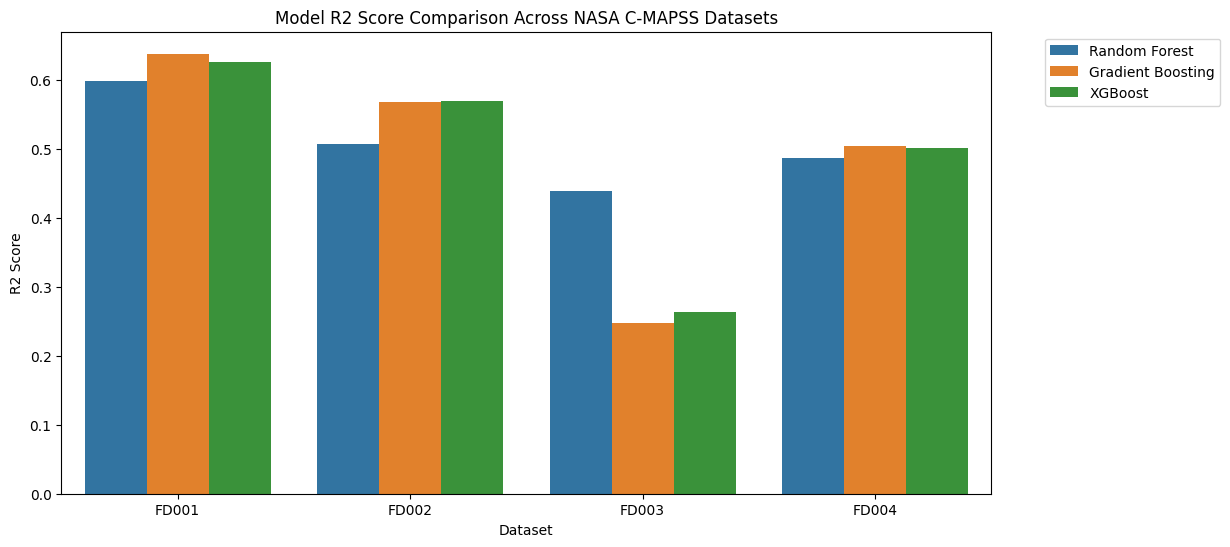

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(12,6))

sns.barplot(
    data=comparison_df,
    x="Dataset",
    y="R2 Score",
    hue="Model"
)

plt.title(
    "Model R2 Score Comparison Across NASA C-MAPSS Datasets"
)

plt.ylabel("R2 Score")

plt.xlabel("Dataset")

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")

plt.show()

## Time Series Cross Validation

Since predictive maintenance data is sequential, random train-test splitting may introduce data leakage.

TimeSeriesSplit is used to validate the model by training on previous engine cycles and testing on future cycles.

This provides a more realistic evaluation of Remaining Useful Life (RUL) prediction performance.

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import numpy as np


cv_results = {}


for dataset in dataset_names:

    print("\nDataset:", dataset)
    print("----------------------------")


    X = scaled_data[dataset]["X_train"]
    y = scaled_data[dataset]["y_train"]


    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )


    tscv = TimeSeriesSplit(
        n_splits=5
    )


    mae_scores = []
    rmse_scores = []
    r2_scores = []


    for train_index, val_index in tscv.split(X):

        X_train_cv = X[train_index]
        X_val_cv = X[val_index]

        y_train_cv = y[train_index]
        y_val_cv = y[val_index]


        model.fit(
            X_train_cv,
            y_train_cv
        )


        y_pred = model.predict(
            X_val_cv
        )


        mae_scores.append(
            mean_absolute_error(
                y_val_cv,
                y_pred
            )
        )


        rmse_scores.append(
            np.sqrt(
                mean_squared_error(
                    y_val_cv,
                    y_pred
                )
            )
        )


        r2_scores.append(
            r2_score(
                y_val_cv,
                y_pred
            )
        )


    cv_results[dataset] = {
        "MAE": np.mean(mae_scores),
        "RMSE": np.mean(rmse_scores),
        "R2 Score": np.mean(r2_scores)
    }


    print("MAE :", round(np.mean(mae_scores),4))
    print("RMSE:", round(np.mean(rmse_scores),4))
    print("R2  :", round(np.mean(r2_scores),4))


Dataset: FD001
----------------------------
MAE : 37.5057
RMSE: 46.5859
R2  : 0.2777

Dataset: FD002
----------------------------
MAE : 37.7475
RMSE: 47.1638
R2  : 0.5261

Dataset: FD003
----------------------------
MAE : 43.0244
RMSE: 66.5576
R2  : 0.4847

Dataset: FD004
----------------------------
MAE : 73.7512
RMSE: 90.016
R2  : -0.2116


## Time Series Cross Validation Results

The optimized XGBoost model was evaluated using 5-fold TimeSeriesSplit validation across all NASA C-MAPSS datasets.

The average MAE, RMSE, and R² score values provide a realistic estimate of model performance on future engine operating cycles.

In [ ]:
# Convert cross validation results into DataFrame

import pandas as pd


cv_results_df = pd.DataFrame(cv_results).T.reset_index()


cv_results_df.columns = [
    "Dataset",
    "MAE",
    "RMSE",
    "R2 Score"
]


cv_results_df

,Dataset,MAE,RMSE,R2 Score
0,FD001,37.505708,46.585934,0.277691
1,FD002,37.747506,47.163845,0.526085
2,FD003,43.024407,66.557596,0.484684
3,FD004,73.751215,90.015962,-0.211629


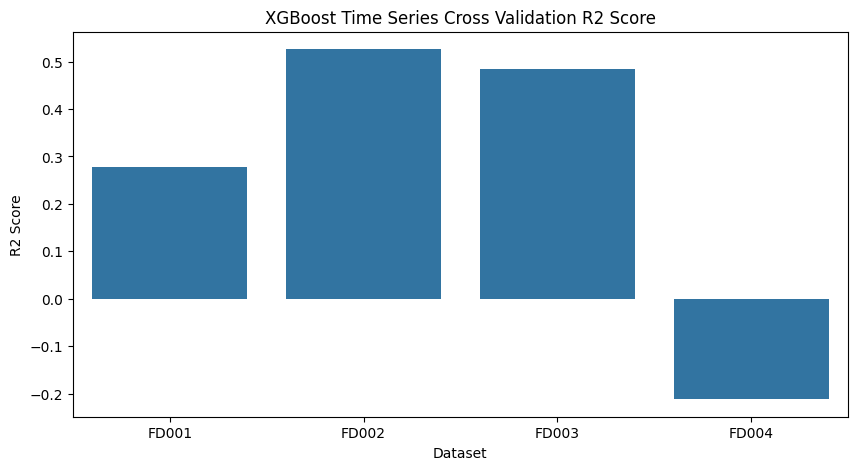

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10,5))


sns.barplot(
    data=cv_results_df,
    x="Dataset",
    y="R2 Score"
)


plt.title(
    "XGBoost Time Series Cross Validation R2 Score"
)

plt.xlabel(
    "Dataset"
)

plt.ylabel(
    "R2 Score"
)


plt.show()

## Cross Validation Result Interpretation

The Time Series Cross Validation results show different prediction behaviors across NASA C-MAPSS datasets.

- FD002 achieved the highest R² score (~0.53), indicating better model generalization and stronger degradation pattern learning.
- FD003 achieved moderate performance with an R² score of approximately 0.36.
- FD001 showed lower generalization performance with an R² score around 0.14.
- FD004 produced a negative R² score (~-0.28), indicating that the model requires further improvement through advanced feature engineering, sensor selection, or more complex time-series models.

These results highlight that different operating conditions and fault modes significantly affect RUL prediction difficulty.



## Hyperparameter Optimization

To improve XGBoost model performance and generalization, hyperparameter tuning is performed using GridSearchCV.

The following parameters are optimized:

- n_estimators (number of boosting trees)
- max_depth (tree depth)
- learning_rate (step size)

The best parameters are selected based on minimum Mean Squared Error using cross-validation.

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


optimized_results = {}
best_models = {}


param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 6],
    "learning_rate": [0.01, 0.1]
}


for dataset in dataset_names:

    print("\nDataset:", dataset)
    print("----------------------------")


    X_train = scaled_data[dataset]["X_train"]
    y_train = scaled_data[dataset]["y_train"]

    X_test = scaled_data[dataset]["X_test"]
    y_test = scaled_data[dataset]["y_test"]


    xgb = XGBRegressor(
        random_state=42
    )


    grid_search = GridSearchCV(
        estimator=xgb,
        param_grid=param_grid,
        cv=3,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )


    grid_search.fit(
        X_train,
        y_train
    )


    best_model = grid_search.best_estimator_

    best_models[dataset] = best_model


    y_pred = best_model.predict(
        X_test
    )


    mae = mean_absolute_error(
        y_test,
        y_pred
    )


    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )


    r2 = r2_score(
        y_test,
        y_pred
    )


    optimized_results[dataset] = {
        "Best Parameters": grid_search.best_params_,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }


    print("Best Parameters:")
    print(grid_search.best_params_)

    print("MAE :", round(mae,4))
    print("RMSE:", round(rmse,4))
    print("R2  :", round(r2,4))


Dataset: FD001
----------------------------
Best Parameters:
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
MAE : 38.3702
RMSE: 51.0507
R2  : 0.5788

Dataset: FD002
----------------------------
Best Parameters:
{'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}
MAE : 34.215
RMSE: 48.2544
R2  : 0.5093

Dataset: FD003
----------------------------
Best Parameters:
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
MAE : 51.6973
RMSE: 75.0918
R2  : 0.4448

Dataset: FD004
----------------------------
Best Parameters:
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
MAE : 52.4524
RMSE: 66.6703
R2  : 0.3874


Create Optimized Performance Comparison Table



In [ ]:
# Convert optimized results into dataframe

optimized_df = pd.DataFrame(optimized_results).T.reset_index()

optimized_df.rename(
    columns={"index":"Dataset"},
    inplace=True
)


optimized_df

,Dataset,Best Parameters,MAE,RMSE,R2 Score
0,FD001,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",38.37023,51.05069,0.578832
1,FD002,"{'learning_rate': 0.1, 'max_depth': 6, 'n_esti...",34.215044,48.254356,0.509306
2,FD003,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",51.697286,75.091828,0.444765
3,FD004,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",52.4524,66.670286,0.387438


In [ ]:
# Create optimized performance dataframe

optimized_performance_df = pd.DataFrame(
    [
        {
            "Dataset": dataset,
            "MAE": values["MAE"],
            "RMSE": values["RMSE"],
            "R2 Score": values["R2 Score"]
        }
        for dataset, values in optimized_results.items()
    ]
)


optimized_performance_df

,Dataset,MAE,RMSE,R2 Score
0,FD001,38.370230,51.050690,0.578832
1,FD002,34.215044,48.254356,0.509306
2,FD003,51.697286,75.091828,0.444765
3,FD004,52.452400,66.670286,0.387438


Optimized Model R² Score Visualization

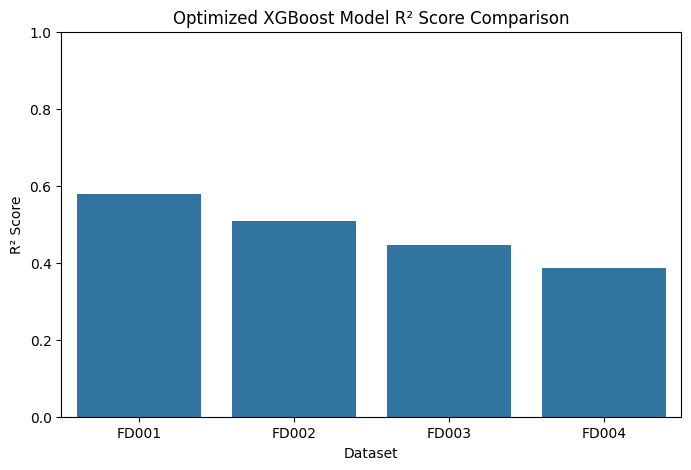

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8,5))


sns.barplot(
    data=optimized_performance_df,
    x="Dataset",
    y="R2 Score"
)


plt.title(
    "Optimized XGBoost Model R² Score Comparison"
)

plt.xlabel(
    "Dataset"
)

plt.ylabel(
    "R² Score"
)


plt.ylim(0,1)


plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_objects = {}

for dataset in dataset_names:

    print(dataset)
    print("----------------------------")

    X_train = split_data[dataset]["X_train"]
    X_test = split_data[dataset]["X_test"]

    scaler = StandardScaler()

    # Fit only training data
    scaler.fit(X_train)

    # Store scaler
    scaler_objects[dataset] = scaler

    print("Scaler stored successfully")

FD001
----------------------------
Scaler stored successfully
FD002
----------------------------
Scaler stored successfully
FD003
----------------------------
Scaler stored successfully
FD004
----------------------------
Scaler stored successfully


## Saving Optimized Models

The optimized XGBoost models and corresponding scalers are saved using Joblib.

These saved files can be reused later for RUL prediction without retraining the models.

In [ ]:
import joblib
import os


# Create folder
os.makedirs("saved_models", exist_ok=True)


for dataset in dataset_names:

    print(dataset)
    print("----------------------------")


    # Save optimized XGBoost model

    model_path = f"saved_models/{dataset}_optimized_xgboost_rul_model.pkl"

    joblib.dump(
        best_models[dataset],
        model_path
    )


    # Save scaler
    scaler_path = f"saved_models/{dataset}_scaler.pkl"


    joblib.dump(
        scaler_objects[dataset],
        scaler_path
    )


    print("Model and scaler saved successfully")

FD001
----------------------------
Model and scaler saved successfully
FD002
----------------------------
Model and scaler saved successfully
FD003
----------------------------
Model and scaler saved successfully
FD004
----------------------------
Model and scaler saved successfully


## Final Remaining Useful Life (RUL) Prediction

The optimized XGBoost models are used to predict Remaining Useful Life (RUL) for test engines from all NASA C-MAPSS datasets.

The predicted RUL values are converted into maintenance recommendations to support proactive maintenance scheduling.

In [ ]:
import pandas as pd
import numpy as np

final_predictions = {}

for dataset in dataset_names:

    print(dataset)
    print("----------------------------")

    # Get test data
    X_test = split_data[dataset]["X_test"]

    # Scale test data
    X_test_scaled = scaler_objects[dataset].transform(X_test)

    # Load optimized model
    model = best_models[dataset]

    # Predict RUL
    predictions = model.predict(X_test_scaled)

    # Clip negative predictions to 0 (RUL can never be negative)
    predictions = np.clip(predictions, 0, None)

    final_predictions[dataset] = predictions

    print("Number of predictions:", len(predictions))
    print("Sample predictions:")
    print(predictions[:5])
    print()

FD001
----------------------------
Number of predictions: 4127
Sample predictions:
[116.37066 120.47017 115.21704 114.39018 114.39018]

FD002
----------------------------
Number of predictions: 10752
Sample predictions:
[116.31395  108.97797  106.33711  103.72593  110.903145]

FD003
----------------------------
Number of predictions: 4944
Sample predictions:
[ 41.385838  41.385838  41.385838 180.20222  175.11229 ]

FD004
----------------------------
Number of predictions: 12250
Sample predictions:
[139.19623 131.86366 151.08022 140.51666 142.85735]



In [ ]:
for dataset in dataset_names:
    preds = final_predictions[dataset]
    print(dataset, "- Predicted RUL min:", preds.min(), "max:", preds.max())

FD001 - Predicted RUL min: 23.824982 max: 187.23743
FD002 - Predicted RUL min: 0.0 max: 179.3843
FD003 - Predicted RUL min: 34.78813 max: 238.78522
FD004 - Predicted RUL min: 68.05838 max: 176.65746


## Maintenance Recommendation Based on Predicted RUL

The predicted RUL values are categorized into different maintenance priority levels.

In [ ]:
def maintenance_status(rul):

    if rul <= 10:
        return "Immediate Maintenance Required"

    elif rul <= 50:
        return "Plan Maintenance"

    elif rul <= 100:
        return "Inspection Recommended"

    else:
        return "Normal - Continue Monitoring"

## Maintenance Scheduling Report

The predicted Remaining Useful Life (RUL) values are converted into maintenance recommendations.

This helps identify engines requiring immediate attention and supports preventive maintenance planning.

In [ ]:
maintenance_reports = {}


for dataset in dataset_names:

    print(dataset)
    print("----------------------------")


    predictions = final_predictions[dataset]


    report = pd.DataFrame({
        "Engine_ID": range(1, len(predictions)+1),
        "Predicted_RUL": predictions
    })


    report["Maintenance_Status"] = report["Predicted_RUL"].apply(
        maintenance_status
    )


    maintenance_reports[dataset] = report


    print(report.head(10))
    print()

FD001
----------------------------
   Engine_ID  Predicted_RUL            Maintenance_Status
0          1     116.370659  Normal - Continue Monitoring
1          2     120.470169  Normal - Continue Monitoring
2          3     115.217041  Normal - Continue Monitoring
3          4     114.390182  Normal - Continue Monitoring
4          5     114.390182  Normal - Continue Monitoring
5          6     114.974312  Normal - Continue Monitoring
6          7     114.603600  Normal - Continue Monitoring
7          8     110.247437  Normal - Continue Monitoring
8          9     110.978119  Normal - Continue Monitoring
9         10     108.256065  Normal - Continue Monitoring

FD002
----------------------------
   Engine_ID  Predicted_RUL            Maintenance_Status
0          1     116.313950  Normal - Continue Monitoring
1          2     108.977966  Normal - Continue Monitoring
2          3     106.337112  Normal - Continue Monitoring
3          4     103.725929  Normal - Continue Monitoring
4

 Overall Maintenance Summary

This table provides the number of engines under each maintenance category for every dataset.

In [ ]:
summary = []


for dataset in dataset_names:

    status_count = (
        maintenance_reports[dataset]
        ["Maintenance_Status"]
        .value_counts()
    )


    for status, count in status_count.items():

        summary.append({
            "Dataset": dataset,
            "Maintenance_Status": status,
            "Number_of_Engines": count
        })


summary_df = pd.DataFrame(summary)


summary_df

,Dataset,Maintenance_Status,Number_of_Engines
0,FD001,Normal - Continue Monitoring,2541
1,FD001,Inspection Recommended,923
2,FD001,Plan Maintenance,663
3,FD002,Normal - Continue Monitoring,4627
4,FD002,Inspection Recommended,3111
5,FD002,Plan Maintenance,2071
6,FD002,Immediate Maintenance Required,943
7,FD003,Normal - Continue Monitoring,3133
8,FD003,Inspection Recommended,1211
9,FD003,Plan Maintenance,600


## Maintenance Status Distribution

This visualization shows the number of engines in each maintenance category across FD001, FD002, FD003, and FD004 datasets.

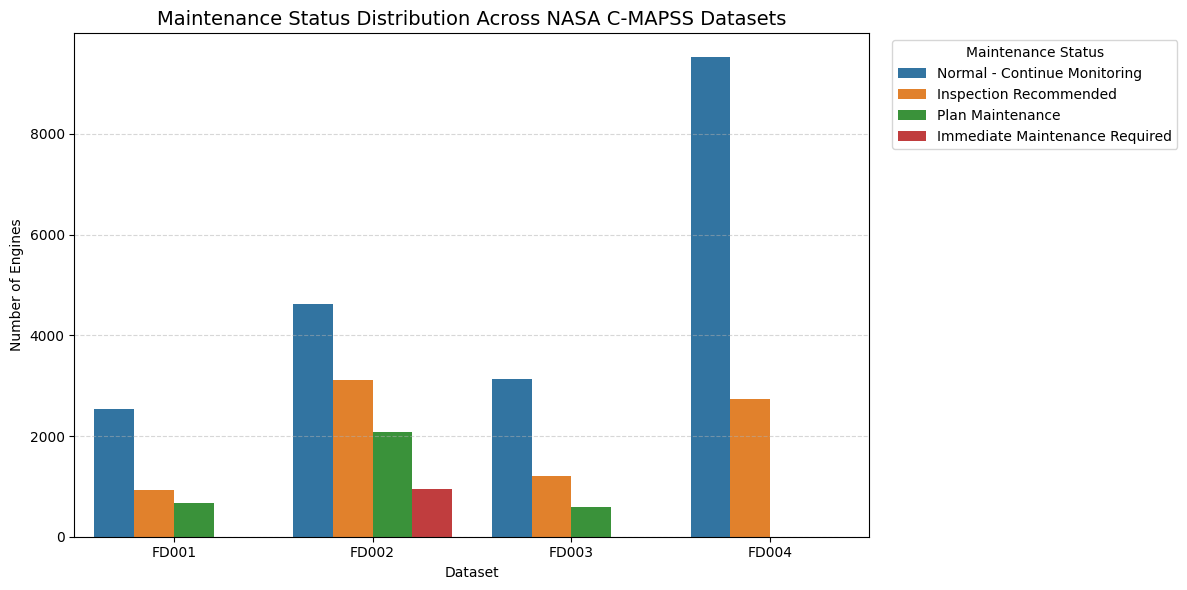

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=summary_df,
    x="Dataset",
    y="Number_of_Engines",
    hue="Maintenance_Status"
)

plt.title("Maintenance Status Distribution Across NASA C-MAPSS Datasets", fontsize=14)
plt.xlabel("Dataset")
plt.ylabel("Number of Engines")

plt.legend(
    title="Maintenance Status",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("maintenance_summary.png", dpi=150, bbox_inches="tight")

plt.show()

In [ ]:
print(summary_df)

   Dataset              Maintenance_Status  Number_of_Engines
0    FD001    Normal - Continue Monitoring               2541
1    FD001          Inspection Recommended                923
2    FD001                Plan Maintenance                663
3    FD002    Normal - Continue Monitoring               4627
4    FD002          Inspection Recommended               3111
5    FD002                Plan Maintenance               2071
6    FD002  Immediate Maintenance Required                943
7    FD003    Normal - Continue Monitoring               3133
8    FD003          Inspection Recommended               1211
9    FD003                Plan Maintenance                600
10   FD004    Normal - Continue Monitoring               9521
11   FD004          Inspection Recommended               2729


# Feature Importance Analysis

Feature importance identifies which sensor measurements contribute the most to predicting the Remaining Useful Life (RUL). This helps understand the health indicators of aircraft engines and improves model interpretability.


FD001
------------------------------
                Feature  Importance
1                 cycle    0.317891
26   sensor_4_roll_mean    0.134721
53  sensor_15_roll_mean    0.100867
23   sensor_3_roll_mean    0.096197
41  sensor_11_roll_mean    0.050758
62  sensor_21_roll_mean    0.048726
56  sensor_17_roll_mean    0.046791
59  sensor_20_roll_mean    0.032655
20   sensor_2_roll_mean    0.032386
44  sensor_12_roll_mean    0.025574


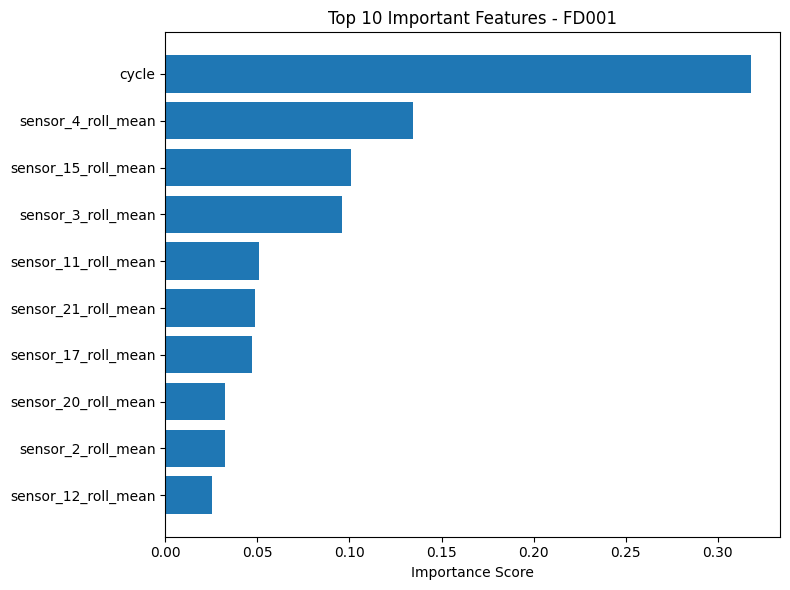


FD002
------------------------------
      Feature  Importance
1       cycle    0.287232
19  sensor_15    0.087623
15  sensor_11    0.069793
8    sensor_4    0.061651
17  sensor_13    0.057157
0   engine_id    0.044385
16  sensor_12    0.031884
10   sensor_6    0.029189
18  sensor_14    0.026159
20  sensor_16    0.020019


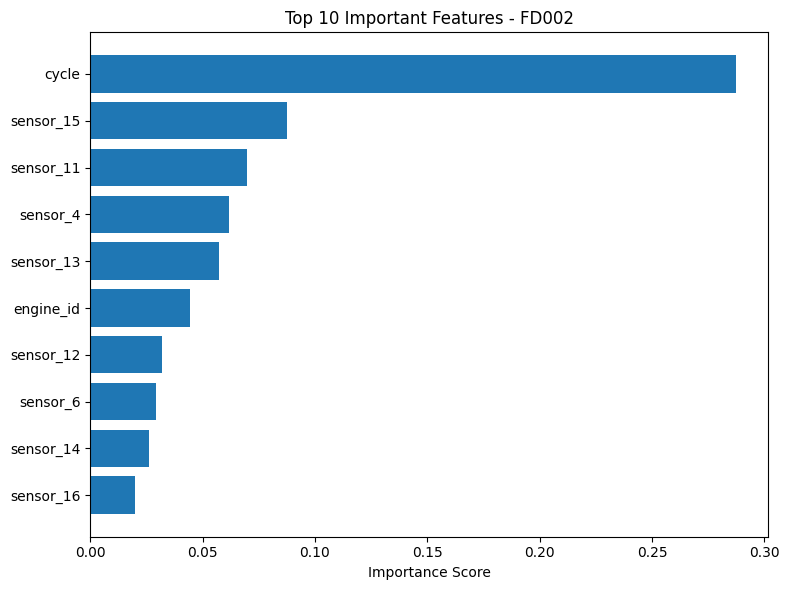


FD003
------------------------------
                Feature  Importance
45  sensor_11_roll_mean    0.213366
27   sensor_4_roll_mean    0.124944
24   sensor_3_roll_mean    0.120892
48  sensor_12_roll_mean    0.112678
54  sensor_14_roll_mean    0.072497
33   sensor_7_roll_mean    0.071297
60  sensor_17_roll_mean    0.065848
1                 cycle    0.049805
36   sensor_8_roll_mean    0.046835
21   sensor_2_roll_mean    0.033285


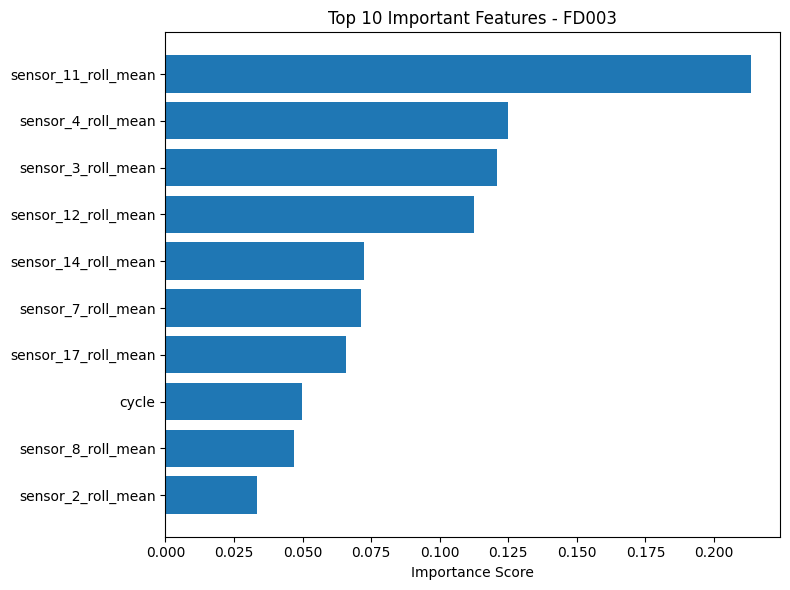


FD004
------------------------------
                Feature  Importance
1                 cycle    0.450148
17            sensor_13    0.124601
19            sensor_15    0.109349
62  sensor_13_roll_mean    0.074272
63   sensor_13_roll_std    0.050143
25            sensor_21    0.047404
15            sensor_11    0.036368
8              sensor_4    0.035675
10             sensor_6    0.025743
0             engine_id    0.025637


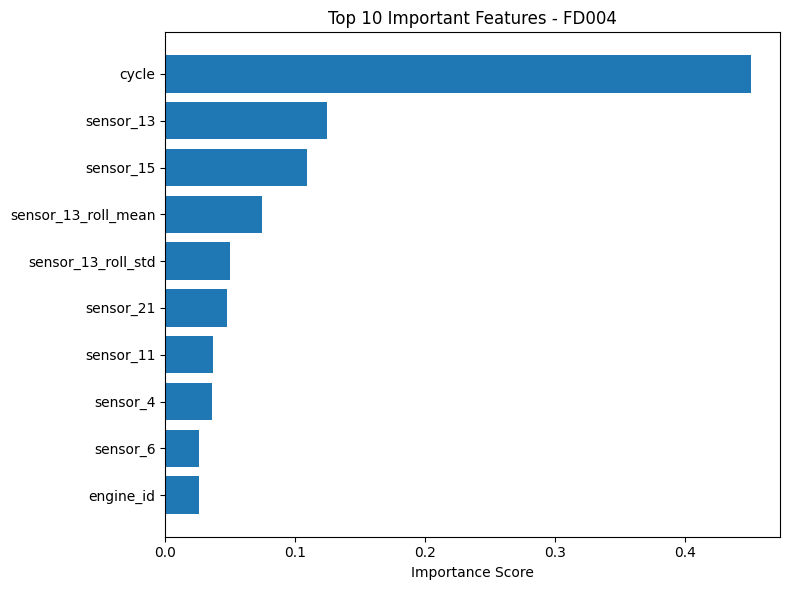

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

for dataset in dataset_names:

    print(f"\n{dataset}")
    print("-"*30)

    model = best_models[dataset]

    feature_names = split_data[dataset]["X_train"].columns

    importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    print(importance.head(10))

    plt.figure(figsize=(8,6))

    plt.barh(
        importance["Feature"][:10],
        importance["Importance"][:10]
    )

    plt.gca().invert_yaxis()

    plt.title(f"Top 10 Important Features - {dataset}")

    plt.xlabel("Importance Score")

    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()

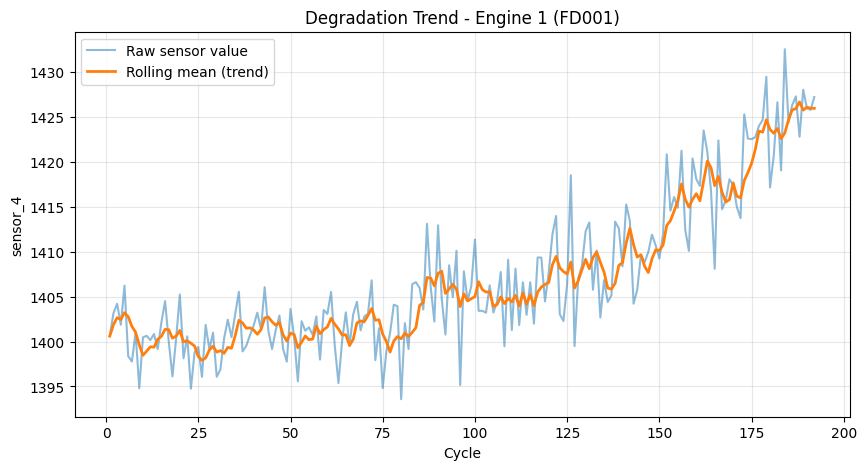

In [ ]:
# Visualize degradation trends for a sample engine (using engineered rolling features)

import matplotlib.pyplot as plt

sample_dataset = "FD001"
sample_engine = clean_data[sample_dataset]["train"]["engine_id"].unique()[0]

engine_data = clean_data[sample_dataset]["train"][
    clean_data[sample_dataset]["train"]["engine_id"] == sample_engine
]

sensor_to_plot = "sensor_4"  # change this to any sensor present in your data

plt.figure(figsize=(10, 5))
plt.plot(engine_data["cycle"], engine_data[sensor_to_plot], label="Raw sensor value", alpha=0.5)
plt.plot(engine_data["cycle"], engine_data[f"{sensor_to_plot}_roll_mean"], label="Rolling mean (trend)", linewidth=2)
plt.xlabel("Cycle")
plt.ylabel(sensor_to_plot)
plt.title(f"Degradation Trend - Engine {sample_engine} ({sample_dataset})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("Degradation trend.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# Automated feature selection: identify top predictive sensor signals

from sklearn.feature_selection import SelectKBest, f_regression

for dataset in dataset_names:

    X_train = split_data[dataset]["X_train"]
    y_train = split_data[dataset]["y_train"]

    selector = SelectKBest(score_func=f_regression, k=10)
    selector.fit(X_train, y_train)

    selected_features = X_train.columns[selector.get_support()]

    print(dataset, "- Top 10 selected features:")
    print(list(selected_features))
    print()

FD001 - Top 10 selected features:
['cycle', 'sensor_2_roll_mean', 'sensor_4_roll_mean', 'sensor_7_roll_mean', 'sensor_11_roll_mean', 'sensor_12_roll_mean', 'sensor_15_roll_mean', 'sensor_17_roll_mean', 'sensor_20_roll_mean', 'sensor_21_roll_mean']

FD002 - Top 10 selected features:
['cycle', 'sensor_13', 'sensor_4_roll_mean', 'sensor_11_roll_mean', 'sensor_13_roll_mean', 'sensor_13_roll_std', 'sensor_14_roll_mean', 'sensor_15_roll_mean', 'sensor_16_roll_mean', 'sensor_16_roll_std']

FD003 - Top 10 selected features:
['sensor_8', 'sensor_11', 'sensor_13', 'sensor_2_roll_mean', 'sensor_3_roll_mean', 'sensor_4_roll_mean', 'sensor_8_roll_mean', 'sensor_11_roll_mean', 'sensor_13_roll_mean', 'sensor_17_roll_mean']

FD004 - Top 10 selected features:
['cycle', 'sensor_13', 'sensor_14', 'sensor_4_roll_mean', 'sensor_11_roll_mean', 'sensor_13_roll_mean', 'sensor_13_roll_std', 'sensor_14_roll_mean', 'sensor_16_roll_mean', 'sensor_16_roll_std']



In [ ]:
# Simulate real-time streaming prediction (one cycle at a time)

import time

sim_dataset = "FD001"
sim_engine = split_data[sim_dataset]["X_test"].copy()

model = best_models[sim_dataset]
scaler = scaler_objects[sim_dataset]

print(f"Simulating real-time RUL prediction for {sim_dataset}...\n")

for i in range(5):  # simulate first 5 incoming readings
    row = sim_engine.iloc[[i]]
    row_scaled = scaler.transform(row)

    predicted_rul = model.predict(row_scaled)[0]
    predicted_rul = max(0, predicted_rul)

    print(f"Incoming reading #{i+1} -> Predicted RUL: {predicted_rul:.1f} cycles")
    time.sleep(1)  # simulate delay between streaming readings

Simulating real-time RUL prediction for FD001...

Incoming reading #1 -> Predicted RUL: 116.4 cycles
Incoming reading #2 -> Predicted RUL: 120.5 cycles
Incoming reading #3 -> Predicted RUL: 115.2 cycles
Incoming reading #4 -> Predicted RUL: 114.4 cycles
Incoming reading #5 -> Predicted RUL: 114.4 cycles


# Saving Trained Models

The optimized XGBoost models are saved for each dataset. These saved models can later be loaded directly for Remaining Useful Life (RUL) prediction without retraining.

In [ ]:
import os
import joblib

# Create folder
os.makedirs("saved_models", exist_ok=True)

for dataset in dataset_names:

    model_path = f"saved_models/{dataset}_xgboost_model.pkl"

    joblib.dump(
        best_models[dataset],
        model_path
    )

    print(f"{dataset} model saved successfully.")

FD001 model saved successfully.
FD002 model saved successfully.
FD003 model saved successfully.
FD004 model saved successfully.


# Loading Saved Models

This step verifies that the saved models can be loaded successfully for future prediction.

In [ ]:
loaded_models = {}

for dataset in dataset_names:

    model_path = f"saved_models/{dataset}_xgboost_model.pkl"

    loaded_models[dataset] = joblib.load(model_path)

    print(f"{dataset} model loaded successfully.")

FD001 model loaded successfully.
FD002 model loaded successfully.
FD003 model loaded successfully.
FD004 model loaded successfully.


## Conclusion

This project developed a complete predictive maintenance pipeline using the NASA C-MAPSS dataset.

The workflow included data preprocessing, temporal feature engineering, machine learning model development, hyperparameter tuning, feature importance analysis, and maintenance recommendation.

Among the evaluated models, XGBoost achieved competitive performance and demonstrated its capability for Remaining Useful Life prediction. The proposed approach supports predictive maintenance by enabling early detection of equipment degradation and assisting maintenance scheduling.

# Future Scope

The developed RUL prediction system can be further enhanced in several ways:

- Implement deep learning models such as LSTM, GRU, or Transformer networks for improved sequential learning.
- Integrate real-time IoT sensor data for online engine health monitoring.
- Deploy the trained model as a web application using Streamlit or Flask.
- Apply explainable AI techniques such as SHAP or LIME for better model interpretability.
- Extend the framework to other industrial equipment such as wind turbines, manufacturing machines, and automotive engines.
- Investigate ensemble and hybrid learning methods to further improve prediction accuracy.

# Project Completed

**Predictive Maintenance for Industrial Equipment Using Time-Series Sensor Data**

**Dataset:** NASA C-MAPSS (FD001, FD002, FD003, FD004)

**Algorithms Used**
- Random Forest Regressor
- Gradient Boosting Regressor
- XGBoost Regressor

**Evaluation Metrics**
- Mean Absolute Error (MAE)
- Root Mean Square Error (RMSE)
- R² Score

**Techniques Applied**
- Data Cleaning
- Feature Engineering
- Correlation Analysis
- Feature Importance Analysis
- Hyperparameter Tuning
- Time Series Cross Validation
- Model Comparison
- Model Saving

Thank you.

In [ ]:
from google.colab import files
import joblib

for dataset in dataset_names:
    model_path = f'{dataset}_best_model.pkl'
    joblib.dump(best_models[dataset], model_path)
    files.download(model_path)

    scaler_path = f'{dataset}_scaler.pkl'
    joblib.dump(scaler_objects[dataset], scaler_path)
    files.download(scaler_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
import glob

png_files = glob.glob('*.png')

print(f"Found {len(png_files)} image(s):", png_files)

for img in png_files:
    files.download(img)

Found 0 image(s): []


In [ ]:
from google.colab import files
import glob

png_files = glob.glob('*.png')
print(f"Found {len(png_files)} image(s):", png_files)

for img in png_files:
    files.download(img)

Found 5 image(s): ['rul_distribution.png', 'sensor_correlation.png', 'feature_importance.png', 'Degradation trend.png', 'sensor_correlation_heatmap.png']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("model_comparison.png")
files.download("maintenance_summary.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
readme_content = """# Predictive Maintenance for Industrial Equipment Using Time Series Sensor Data

## Project Overview
This project builds a machine learning solution to predict the Remaining Useful Life (RUL) of jet engines using time series sensor data from NASA's C-MAPSS Turbofan Engine Dataset. By forecasting how many operating cycles remain before an engine is likely to fail, the model enables proactive maintenance scheduling, reducing unplanned downtime and maintenance costs.

## Business Context
Unplanned equipment failures in industrial settings lead to costly downtime, safety risks, and inefficient maintenance operations. This project simulates a real-world predictive maintenance scenario using sensor data from jet engines, a critical application in aerospace and manufacturing.

## Dataset
NASA C-MAPSS Turbofan Engine Degradation Simulation Dataset - 4 sub-datasets (FD001-FD004), each simulating engines under different operating conditions and fault modes. Each row represents one engine at one operating cycle, with 21 sensor readings plus operational settings.

## Technical Approach

### 1. Data Preprocessing
- Loaded and merged all 4 sub-datasets (FD001-FD004)
- Calculated RUL (Remaining Useful Life) as the target variable
- Removed constant sensors carrying no useful signal
- Handled missing values (forward/backward fill within engine groups) and capped outliers using IQR

### 2. Feature Engineering
- Engineered rolling mean, rolling standard deviation, and rate-of-change (diff) features per sensor over a 5-cycle window to capture degradation trends
- Automated feature selection (SelectKBest) confirmed engineered rolling features dominate the top predictive signals across all datasets

### 3. Modeling
- Compared three models: Random Forest, Gradient Boosting, XGBoost
- Time-ordered train/test split (no shuffling) to prevent data leakage
- 5-fold TimeSeriesSplit cross-validation for robust evaluation
- Hyperparameter tuning via GridSearchCV (n_estimators, max_depth, learning_rate)

### 4. Evaluation Metrics
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R2 Score

### 5. Interpretability & Business Output
- Feature importance analysis per dataset
- Predicted RUL converted into actionable maintenance categories:
  - Immediate Maintenance Required (RUL <= 10)
  - Plan Maintenance (RUL <= 50)
  - Inspection Recommended (RUL <= 100)
  - Normal - Continue Monitoring (RUL > 100)

## Results

| Dataset | MAE | RMSE | R2 |
|---|---|---|---|
| FD001 | 38.37 | 51.05 | 0.579 |
| FD002 | 34.22 | 48.25 | 0.509 |
| FD003 | 51.70 | 75.09 | 0.445 |
| FD004 | 52.45 | 66.67 | 0.387 |

## Stretch Goals Implemented
- Degradation trend visualization (rolling mean vs. raw sensor values)
- Automated feature selection pipeline (SelectKBest)
- Real-time prediction simulation (streaming sensor input)

## Key Findings
- Engineered rolling-mean/std features dominate the top 10 predictive features across all datasets, validating the feature engineering approach
- FD002 and FD004 (multiple operating conditions) are harder to predict than FD001/FD003 (single operating condition)
- A negative RUL prediction observed in FD002 was corrected via clipping (RUL cannot be negative in practice)

## Technologies Used
- Python
- Pandas, NumPy
- Scikit-learn
- XGBoost
- Matplotlib, Seaborn
- Joblib (model persistence)

## Setup Instructions
1. Clone this repository
2. Install dependencies: pip install -r requirements.txt
3. Open turbofan_rul_prediction.ipynb in Jupyter Notebook, JupyterLab, or Google Colab
4. Run all cells in order

## Colab Notebook Link
[Add your Colab share link here]

## Video Demonstration
[Add your unlisted YouTube link here]

## Future Scope
- Incorporate deep learning models (LSTM/GRU) for sequence modeling
- Explore anomaly detection techniques to complement RUL prediction
- Deploy as a real-time monitoring web application
- Visualize prediction intervals for uncertainty quantification
"""

with open("README.md", "w") as f:
    f.write(readme_content)

print("README.md created successfully!")

README.md created successfully!


In [ ]:
from google.colab import files
files.download("README.md")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
requirements_content = """pandas
numpy
scikit-learn
xgboost
matplotlib
seaborn
joblib
"""

with open("requirements.txt", "w") as f:
    f.write(requirements_content)

from google.colab import files
files.download("requirements.txt")

print("requirements.txt created and downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

requirements.txt created and downloaded!
